# Answer BQ-01 through BQ-06

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import datetime as dt
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

%matplotlib inline

## What is the month-on-month trend in total orders and Gross Merchandise Value (GMV) over the full dataset period?

In [2]:
try:
   orders=pd.read_parquet('orders.parquet')
except Exception as e:
   print("something went wrong: " + e.message)


In [3]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [4]:
try:
  order_items=pd.read_parquet('order_items.parquet')
except Exception as e:
  print("something went wrong: " + e.message)

In [5]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [6]:
orders_order_items=pd.merge(orders,order_items,on='order_id')

In [7]:
orders_order_items['month_year'] = orders_order_items['order_purchase_timestamp'].dt.to_period('M')

In [8]:
orders_order_items.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,month_year
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,2018-02


In [24]:
month_on_month_trend=orders_order_items.groupby(['month_year']).agg({
    'order_id':'nunique','price':'sum','freight_value':'sum'
    }).rename(columns={
        'order_id':'total_orders','price':'total_price','freight_value':'total_freight_value'
        }).reset_index()
month_on_month_trend['GMV']=month_on_month_trend['total_price']+month_on_month_trend['total_freight_value']
month_on_month_trend['month_year'] = pd.to_datetime(
    month_on_month_trend['month_year'].astype(str),
    format='%Y-%m'
)


month_on_month_trend = month_on_month_trend.sort_values('month_year')

month_on_month_trend

,month_year,total_orders,total_price,total_freight_value,GMV
0,2016-09-01,3,267.36,87.39,354.75
1,2016-10-01,308,49507.66,7301.18,56808.84
2,2016-12-01,1,10.90,8.72,19.62
3,2017-01-01,789,120312.87,16875.62,137188.49
4,2017-02-01,1733,247303.02,38977.60,286280.62
5,2017-03-01,2641,374344.30,57704.29,432048.59
6,2017-04-01,2391,359927.23,52495.01,412422.24
7,2017-05-01,3660,506071.14,80119.81,586190.95
8,2017-06-01,3217,433038.60,69924.44,502963.04
9,2017-07-01,3969,498031.48,86940.14,584971.62


## Visual plots of the results

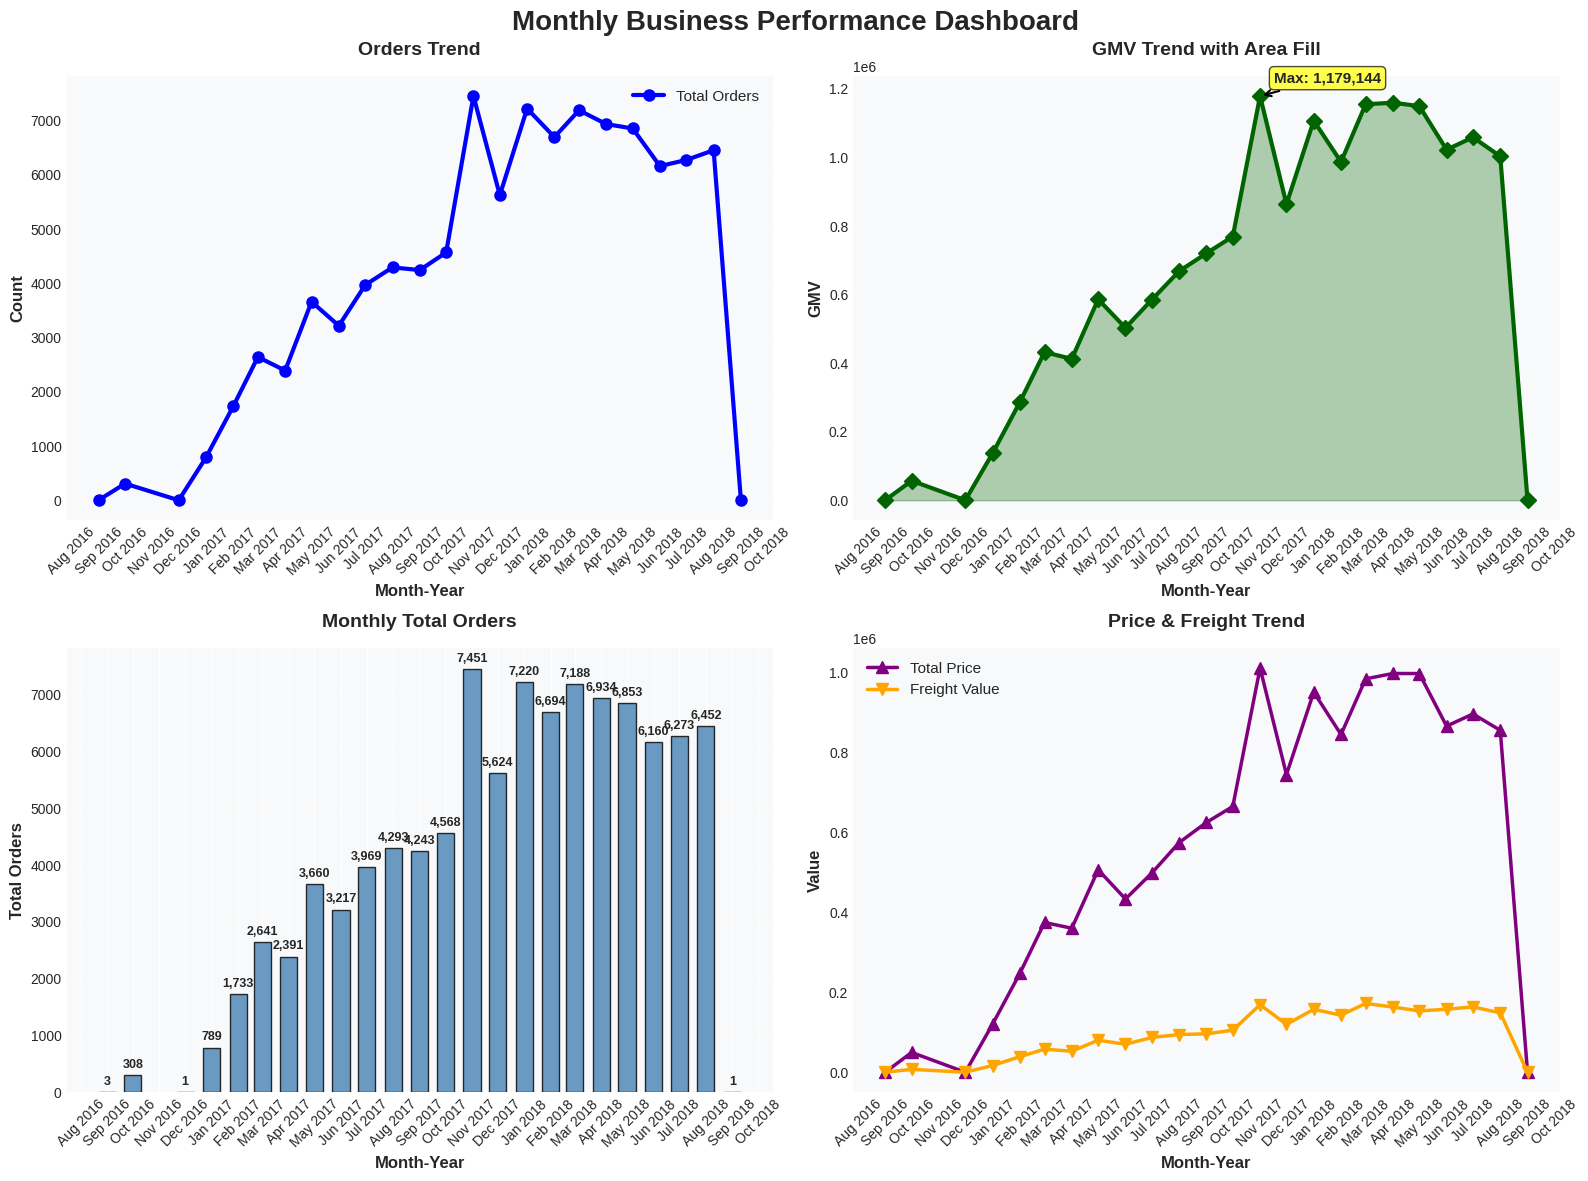

In [23]:

# Set style for better looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Monthly Business Performance Dashboard', fontsize=20, fontweight='bold', y=0.98)

# 1. Total Orders & GMV Trend
ax1 = axes[0, 0]
ax1.plot(month_on_month_trend['month_year'], month_on_month_trend['total_orders'],
         color='blue', linewidth=3, marker='o', markersize=8, label='Total Orders')
ax1.set_xlabel('Month-Year', fontsize=12, fontweight='bold')
ax1.set_ylabel('Count', fontsize=12, fontweight='bold')
ax1.set_title('Orders Trend', fontsize=14, fontweight='bold', pad=15)
ax1.legend(loc='best', fontsize=11, framealpha=0.9)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.tick_params(axis='x', rotation=45, labelsize=10)
ax1.tick_params(axis='y', labelsize=10)
ax1.set_facecolor('#f8f9fa')

# 2. GMV Only with Area Fill
ax2 = axes[0, 1]
ax2.plot(month_on_month_trend['month_year'], month_on_month_trend['GMV'],
         color='darkgreen', linewidth=3, marker='D', markersize=8)
ax2.fill_between(month_on_month_trend['month_year'], 0, month_on_month_trend['GMV'],
                 alpha=0.3, color='darkgreen')
ax2.set_xlabel('Month-Year', fontsize=12, fontweight='bold')
ax2.set_ylabel('GMV', fontsize=12, fontweight='bold')
ax2.set_title('GMV Trend with Area Fill', fontsize=14, fontweight='bold', pad=15)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator())
ax2.tick_params(axis='x', rotation=45, labelsize=10)
ax2.tick_params(axis='y', labelsize=10)
ax2.set_facecolor('#f8f9fa')

# Annotate max value
max_gmv = month_on_month_trend['GMV'].max()
max_date = month_on_month_trend.loc[month_on_month_trend['GMV'].idxmax(), 'month_year']
ax2.annotate(f'Max: {max_gmv:,.0f}',
             xy=(max_date, max_gmv),
             xytext=(10, 10), textcoords='offset points',
             fontsize=11, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7),
             arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

# 3. Total Orders with Bar Chart
ax3 = axes[1, 0]
bars = ax3.bar(month_on_month_trend['month_year'], month_on_month_trend['total_orders'],
               width=20, alpha=0.8, color='steelblue', edgecolor='black', linewidth=1)
ax3.set_xlabel('Month-Year', fontsize=12, fontweight='bold')
ax3.set_ylabel('Total Orders', fontsize=12, fontweight='bold')
ax3.set_title('Monthly Total Orders', fontsize=14, fontweight='bold', pad=15)
ax3.grid(True, alpha=0.3, linestyle='--', axis='y')
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax3.xaxis.set_major_locator(mdates.MonthLocator())
ax3.tick_params(axis='x', rotation=45, labelsize=10)
ax3.tick_params(axis='y', labelsize=10)
ax3.set_facecolor('#f8f9fa')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + max(month_on_month_trend['total_orders'])*0.01,
             f'{height:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 4. Combined Metrics Comparison
ax4 = axes[1, 1]
ax4.plot(month_on_month_trend['month_year'], month_on_month_trend['total_price'],
         color='purple', linewidth=2.5, marker='^', markersize=8, label='Total Price')
ax4.plot(month_on_month_trend['month_year'], month_on_month_trend['total_freight_value'],
         color='orange', linewidth=2.5, marker='v', markersize=8, label='Freight Value')
ax4.set_xlabel('Month-Year', fontsize=12, fontweight='bold')
ax4.set_ylabel('Value', fontsize=12, fontweight='bold')
ax4.set_title('Price & Freight Trend', fontsize=14, fontweight='bold', pad=15)
ax4.legend(loc='best', fontsize=11, framealpha=0.9)
ax4.grid(True, alpha=0.3, linestyle='--')
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax4.xaxis.set_major_locator(mdates.MonthLocator())
ax4.tick_params(axis='x', rotation=45, labelsize=10)
ax4.tick_params(axis='y', labelsize=10)
ax4.set_facecolor('#f8f9fa')

# Adjust layout
plt.tight_layout()
plt.savefig('monthly_business_dashboard.png', dpi=300, bbox_inches='tight', facecolor='white')

plt.savefig('monthly_business_dashboard.pdf', bbox_inches='tight', facecolor='white')
plt.show()


# Which months exhibit the strongest seasonal peaks, and what is the year-over-year growth rate?

In [26]:
# Filter out boundary artefacts (months with < 400 orders)
month_on_month_trend = month_on_month_trend[month_on_month_trend['total_orders'] >= 400].copy()

# Calculate MoM growth rates
month_on_month_trend['orders_mom_growth'] = month_on_month_trend['total_orders'].pct_change() * 100
month_on_month_trend['gmv_mom_growth']    = month_on_month_trend['GMV'].pct_change() * 100
month_on_month_trend['price_mom_growth']  = month_on_month_trend['total_price'].pct_change() * 100
month_on_month_trend['freight_mom_growth']= month_on_month_trend['total_freight_value'].pct_change() * 100

# First row will be NaN (no prior month) — expected
month_on_month_trend

,month_year,total_orders,total_price,total_freight_value,GMV,orders_mom_growth,gmv_mom_growth,price_mom_growth,freight_mom_growth
3,2017-01-01,789,120312.87,16875.62,137188.49,NaN,NaN,NaN,NaN
4,2017-02-01,1733,247303.02,38977.60,286280.62,119.645120,108.676850,105.549930,130.969884
5,2017-03-01,2641,374344.30,57704.29,432048.59,52.394691,50.917862,51.370695,48.044749
6,2017-04-01,2391,359927.23,52495.01,412422.24,-9.466111,-4.542626,-3.851286,-9.027544
7,2017-05-01,3660,506071.14,80119.81,586190.95,53.074028,42.133690,40.603738,52.623668
8,2017-06-01,3217,433038.60,69924.44,502963.04,-12.103825,-14.198089,-14.431279,-12.725155
9,2017-07-01,3969,498031.48,86940.14,584971.62,23.375816,16.305091,15.008565,24.334410
10,2017-08-01,4293,573971.68,94232.92,668204.60,8.163265,14.228550,15.248072,8.388277
11,2017-09-01,4243,624401.69,95997.22,720398.91,-1.164687,7.811127,8.786150,1.872276
12,2017-10-01,4568,664219.43,105092.94,769312.37,7.659675,6.789774,6.376943,9.474983


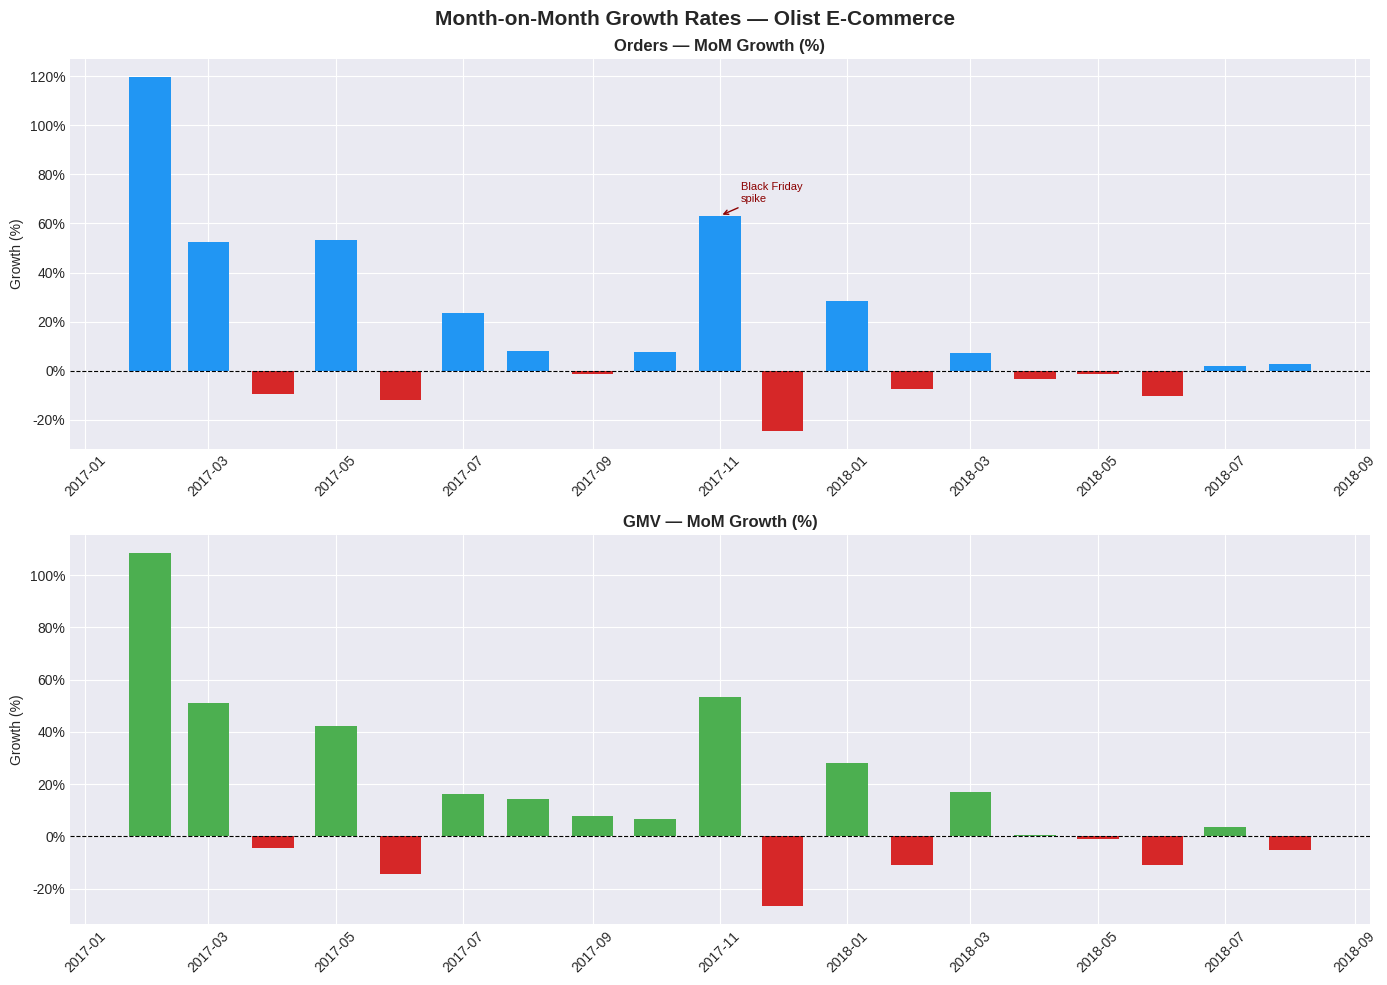

In [32]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Month-on-Month Growth Rates — Olist E-Commerce', fontsize=15, fontweight='bold')

x = month_on_month_trend['month_year']

# --- Orders MoM ---
ax1 = axes[0]
bars = ax1.bar(x, month_on_month_trend['orders_mom_growth'], color=[
    '#d62728' if v < 0 else '#2196F3' for v in month_on_month_trend['orders_mom_growth']
], width=20)
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax1.set_title('Orders — MoM Growth (%)', fontweight='bold')
ax1.set_ylabel('Growth (%)')
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax1.tick_params(axis='x', rotation=45)

# Annotate Nov 2017 spike
nov_2017 = month_on_month_trend[month_on_month_trend['month_year'].dt.to_period('M') == '2017-11']
if not nov_2017.empty:
    ax1.annotate('Black Friday\nspike',
        xy=(nov_2017['month_year'].values[0], nov_2017['orders_mom_growth'].values[0]),
        xytext=(15, 10), textcoords='offset points',
        fontsize=8, color='darkred',
        arrowprops=dict(arrowstyle='->', color='darkred'))

# --- GMV MoM ---
ax2 = axes[1]
ax2.bar(x, month_on_month_trend['gmv_mom_growth'], color=[
    '#d62728' if v < 0 else '#4CAF50' for v in month_on_month_trend['gmv_mom_growth']
], width=20)
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_title('GMV — MoM Growth (%)', fontweight='bold')
ax2.set_ylabel('Growth (%)')
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('mom_growth_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

In [34]:
# YoY — same-period comparison (Jan–Aug only, full coverage in both 2017 and 2018)
month_on_month_trend['year']  = month_on_month_trend['month_year'].dt.year
month_on_month_trend['month'] = month_on_month_trend['month_year'].dt.month

yoy = month_on_month_trend[month_on_month_trend['month'].between(1, 8)].copy()

yoy_2017 = yoy[yoy['year'] == 2017].set_index('month')
yoy_2018 = yoy[yoy['year'] == 2018].set_index('month')

yoy_comparison = pd.DataFrame({
    'orders_2017':       yoy_2017['total_orders'],
    'orders_2018':       yoy_2018['total_orders'],
    'gmv_2017':          yoy_2017['GMV'],
    'gmv_2018':          yoy_2018['GMV'],
})

yoy_comparison['orders_yoy_growth'] = (
    (yoy_comparison['orders_2018'] - yoy_comparison['orders_2017']) / yoy_comparison['orders_2017']
) * 100

yoy_comparison['gmv_yoy_growth'] = (
    (yoy_comparison['gmv_2018'] - yoy_comparison['gmv_2017']) / yoy_comparison['gmv_2017']
) * 100

month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug']
yoy_comparison.index = month_labels

yoy_comparison

,orders_2017,orders_2018,gmv_2017,gmv_2018,orders_yoy_growth,gmv_yoy_growth
Jan,789,7220,137188.49,1107301.89,815.082383,707.139061
Feb,1733,6694,286280.62,986908.96,286.266590,244.734813
Mar,2641,7188,432048.59,1155126.82,172.169633,167.360396
Apr,2391,6934,412422.24,1159698.04,190.004182,181.191926
May,3660,6853,586190.95,1149781.82,87.240437,96.144587
Jun,3217,6160,502963.04,1022677.11,91.482748,103.330469
Jul,3969,6273,584971.62,1058728.03,58.049887,80.987931
Aug,4293,6452,668204.60,1003308.47,50.291172,50.149890


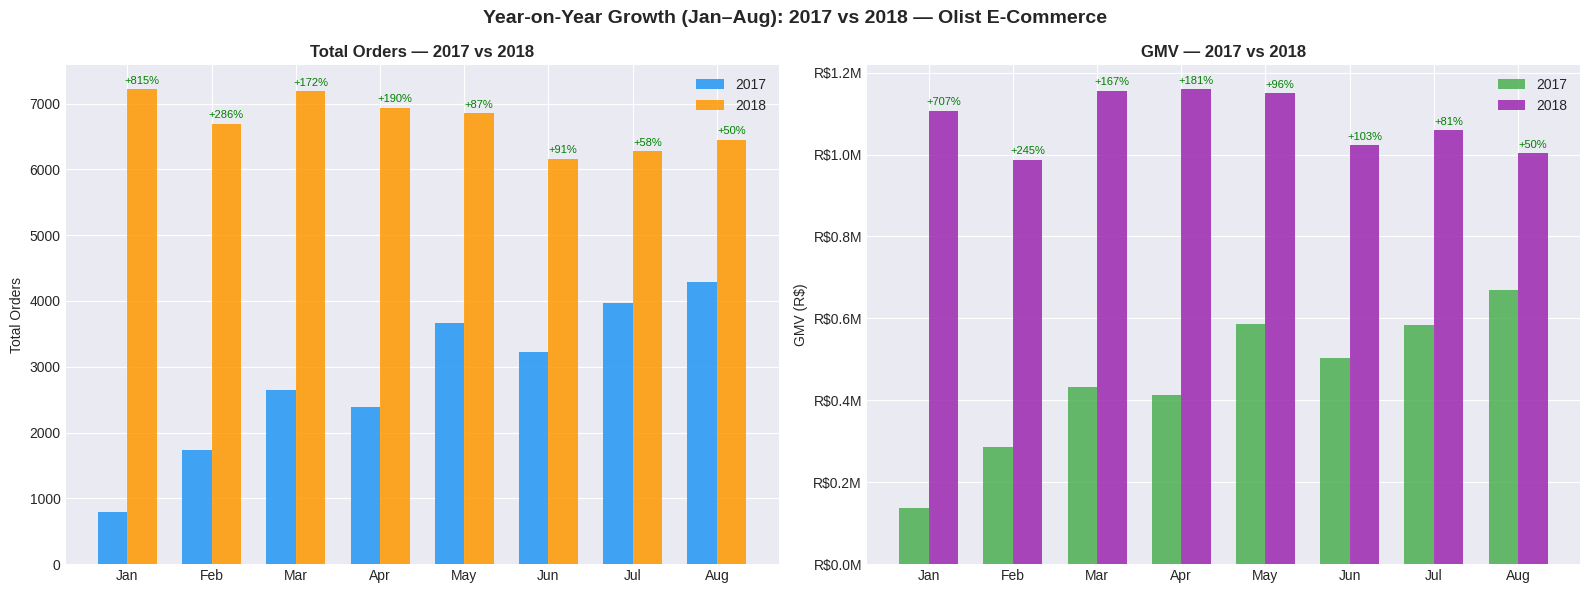

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Year-on-Year Growth (Jan–Aug): 2017 vs 2018 — Olist E-Commerce',
             fontsize=14, fontweight='bold')

x = range(len(month_labels))
width = 0.35

# --- Orders YoY grouped bar ---
ax1 = axes[0]
ax1.bar([i - width/2 for i in x], yoy_comparison['orders_2017'],
        width=width, label='2017', color='#2196F3', alpha=0.85)
ax1.bar([i + width/2 for i in x], yoy_comparison['orders_2018'],
        width=width, label='2018', color='#FF9800', alpha=0.85)
ax1.set_title('Total Orders — 2017 vs 2018', fontweight='bold')
ax1.set_ylabel('Total Orders')
ax1.set_xticks(list(x))
ax1.set_xticklabels(month_labels)
ax1.legend()

# Annotate YoY growth % above each 2018 bar
for i, (_, row) in enumerate(yoy_comparison.iterrows()):
    ax1.annotate(f"{row['orders_yoy_growth']:+.0f}%",
        xy=(i + width/2, row['orders_2018']),
        xytext=(0, 4), textcoords='offset points',
        ha='center', fontsize=8,
        color='green' if row['orders_yoy_growth'] > 0 else 'red')

# --- GMV YoY grouped bar ---
ax2 = axes[1]
ax2.bar([i - width/2 for i in x], yoy_comparison['gmv_2017'],
        width=width, label='2017', color='#4CAF50', alpha=0.85)
ax2.bar([i + width/2 for i in x], yoy_comparison['gmv_2018'],
        width=width, label='2018', color='#9C27B0', alpha=0.85)
ax2.set_title('GMV — 2017 vs 2018', fontweight='bold')
ax2.set_ylabel('GMV (R$)')
ax2.set_xticks(list(x))
ax2.set_xticklabels(month_labels)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'R${v/1e6:.1f}M'))
ax2.legend()

for i, (_, row) in enumerate(yoy_comparison.iterrows()):
    ax2.annotate(f"{row['gmv_yoy_growth']:+.0f}%",
        xy=(i + width/2, row['gmv_2018']),
        xytext=(0, 4), textcoords='offset points',
        ha='center', fontsize=8,
        color='green' if row['gmv_yoy_growth'] > 0 else 'red')

plt.tight_layout()
plt.savefig('yoy_growth_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()